Min-Max Scaled Values:
 [0.09509202 0.08194566 0.07405784 ... 0.69982472 0.68361087 0.68799299]
Standardized Values:
 [-1.0182253  -1.06658457 -1.09560013 ...  1.20630094  1.14665785
  1.1627776 ]
First Difference:
 date
2024-12-24 00:15:11   -3.0
2024-12-24 00:30:11   -1.8
2024-12-24 00:45:11   -2.2
2024-12-24 01:00:15   -3.4
2024-12-24 01:15:11   -1.4
Name: values, dtype: float64
First Derivative (Rate of Change):
 [-3.  -2.4 -2.  -2.8 -2.4]
Second Derivative (Acceleration):
 [ 0.6    0.5   -0.2   -0.2    0.675]
Rolling Mean (window=3):
 date
2024-12-24 00:00:14           NaN
2024-12-24 00:15:11           NaN
2024-12-24 00:30:11    160.400000
2024-12-24 00:45:11    158.066667
2024-12-24 01:00:15    155.600000
Name: values, dtype: float64
Seasonal Component Head:
 date
2024-12-24 00:00:14    0.176268
2024-12-24 00:15:11    0.397480
2024-12-24 00:30:11    0.311554
2024-12-24 00:45:11    0.321548
2024-12-24 01:00:15   -0.243283
Name: seasonal, dtype: float64
Time-Based Features:
       

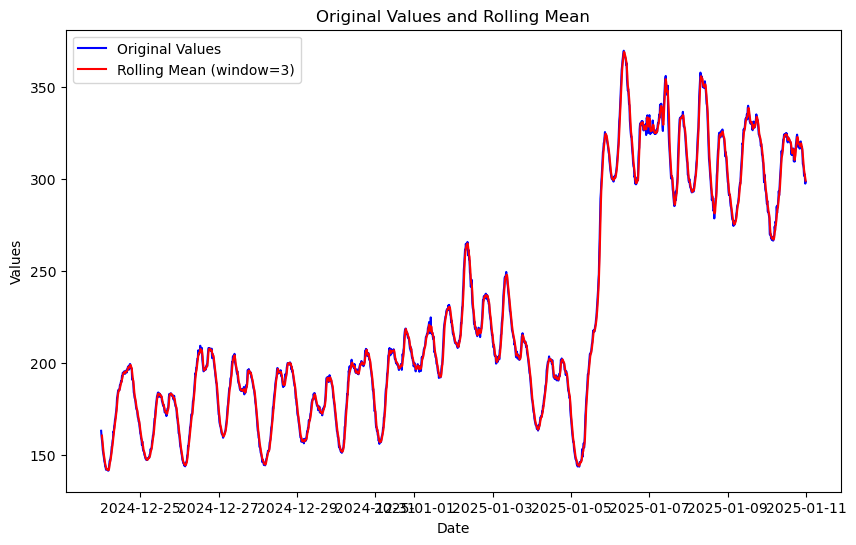

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose

# Load ERCOT Data
df = pd.read_csv("ercot_load_data.csv")
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)
df.sort_index(inplace=True)

# Filter data
df = df[df["values"] >= 60]
values = df["values"]
dates = df.index

# Scaling: Min-Max and Standardization
scaler_minmax = MinMaxScaler()
scaler_std = StandardScaler()

values_scaled_minmax = scaler_minmax.fit_transform(values.values.reshape(-1, 1))
values_scaled_std = scaler_std.fit_transform(values.values.reshape(-1, 1))

print("Min-Max Scaled Values:\n", values_scaled_minmax.flatten())
print("Standardized Values:\n", values_scaled_std.flatten())

# First Difference
values_diff = values.diff().dropna()
print("First Difference:\n", values_diff.head())

# First and Second Derivative (Rate of Change and Acceleration)
values_gradient = np.gradient(values)
values_acceleration = np.gradient(values_gradient)
print("First Derivative (Rate of Change):\n", values_gradient[:5])
print("Second Derivative (Acceleration):\n", values_acceleration[:5])

# Rolling Mean
rolling_mean = values.rolling(window=3).mean()
print("Rolling Mean (window=3):\n", rolling_mean.head())

# Seasonal Decomposition
seasonal_decomposition = seasonal_decompose(values, period=12, model="additive")
print("Seasonal Component Head:\n", seasonal_decomposition.seasonal.head())

# Create Lagged Features and Rate of Change
df_features = pd.DataFrame(
    {
        "value": values,
        "lag_1": values.shift(1),
        "lag_2": values.shift(2),
        "rate_of_change": values.diff(),
    }
).dropna()

# Adding Time-Based Features
df_features["month"] = df_features.index.month
df_features["year"] = df_features.index.year
print("Time-Based Features:\n", df_features[["month", "year"]].head())

# Save rolling mean plot (if desired visualization)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(values, label="Original Values", color="Blue")
plt.plot(rolling_mean, label="Rolling Mean (window=3)", color="Red")
plt.title("Original Values and Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Values")
plt.legend()
plt.savefig("rolling_mean_ercot.png")
plt.show()

/var/folders/c8/g7bx7g1552g19xn4q4dd583r0000gn/T/ipykernel_45562/1678837156.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.set_index('date').resample('H').mean().reset_index()  # Resample to hourly frequency
/opt/anaconda3/lib/python3.12/site-packages/darts/timeseries.py:4866: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampled_time_index = resampled_time_index.asfreq(freq)
/opt/anaconda3/lib/python3.12/site-packages/darts/timeseries.py:4866: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampled_time_index = resampled_time_index.asfreq(freq)


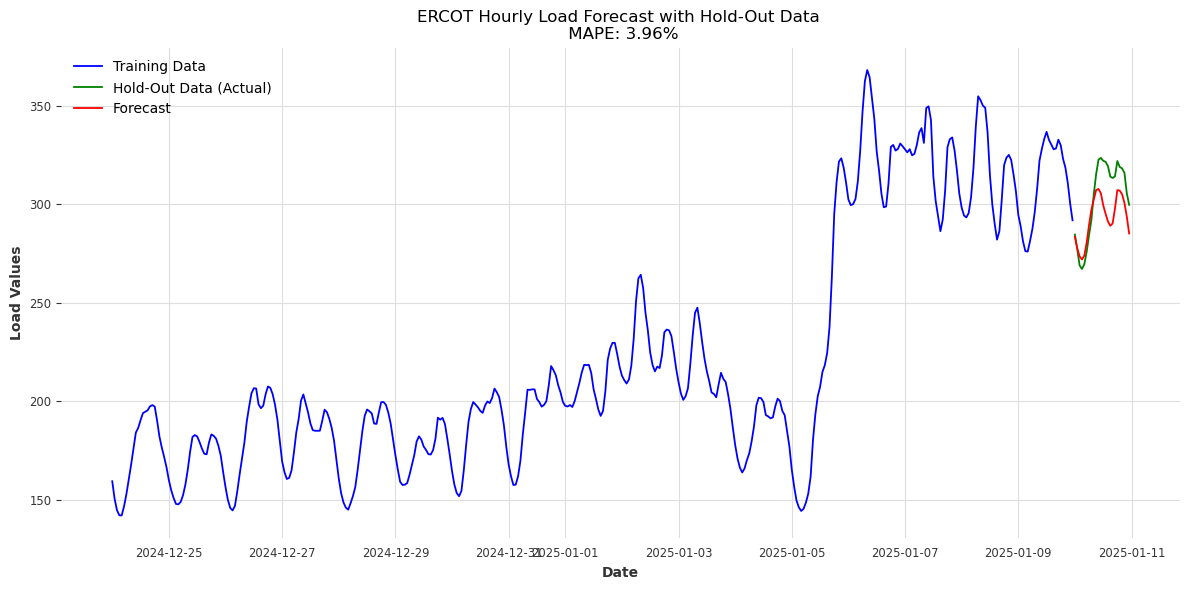

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from darts import TimeSeries
from darts.metrics import mape
from darts.models import ExponentialSmoothing

# Load the ERCOT data
df = pd.read_csv("ercot_load_data.csv")
df["date"] = pd.to_datetime(df["date"])  # Ensure 'date' is in datetime format
df["values"] = pd.to_numeric(
    df["values"], errors="coerce"
)  # Convert 'values' to numeric
df = df.sort_values("date")  # Sort by date

# Drop rows with missing or NaN values
df = df.dropna()

# Resample the data to hourly frequency (mean aggregation)
df = (
    df.set_index("date").resample("H").mean().reset_index()
)  # Resample to hourly frequency

# Define hold-out period (e.g., last 24 hours)
hold_out_hours = 24  # Hold-out size (24 hours = 1 day)
train = df.iloc[:-hold_out_hours]
hold_out = df.iloc[-hold_out_hours:]

# Create TimeSeries for training and hold-out data
series_train = TimeSeries.from_dataframe(
    train, "date", "values", freq="H", fill_missing_dates=True
)
series_hold_out = TimeSeries.from_dataframe(hold_out, "date", "values", freq="H")

# Fit the Exponential Smoothing model on training data
model = ExponentialSmoothing()
model.fit(series_train)

# Forecast the hold-out period
forecast = model.predict(len(series_hold_out))

# Calculate MAPE (Mean Absolute Percentage Error)
mape_result = mape(series_hold_out, forecast)

# Plot the results
plt.figure(figsize=(12, 6))

# Plot training data
plt.plot(
    series_train.time_index, series_train.values(), label="Training Data", color="blue"
)

# Plot hold-out data
plt.plot(
    series_hold_out.time_index,
    series_hold_out.values(),
    label="Hold-Out Data (Actual)",
    color="green",
)

# Plot forecasted data
plt.plot(forecast.time_index, forecast.values(), label="Forecast", color="red")

# Add title and labels
plt.title(f"ERCOT Hourly Load Forecast with Hold-Out Data \n MAPE: {mape_result:.2f}%")
plt.xlabel("Date")
plt.ylabel("Load Values")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the plot
plt.savefig("ERCOT_Hourly_HoldOut_Forecast.png")
plt.show()

Min-Max Scaled Train Values:
 [7.67531750e-02 3.74378796e-02 1.19271121e-02 3.31308669e-04
 0.00000000e+00 2.04307013e-02 4.78188846e-02 8.08393153e-02
 1.13970182e-01 1.49530646e-01 1.85974600e-01 1.96576477e-01
 2.13804528e-01 2.29596908e-01 2.32799558e-01 2.36002209e-01
 2.44947543e-01 2.47708448e-01 2.44616234e-01 2.13031474e-01
 1.77139702e-01 1.52401988e-01 1.31308669e-01 1.07896190e-01
 7.91827719e-02 5.65433462e-02 3.93152954e-02 2.58420762e-02
 2.48481502e-02 3.02595251e-02 4.54997239e-02 6.92435119e-02
 1.02484815e-01 1.42904473e-01 1.76145776e-01 1.80452789e-01
 1.77360574e-01 1.64770845e-01 1.50303700e-01 1.38487024e-01
 1.37272225e-01 1.63666483e-01 1.81888459e-01 1.78796245e-01
 1.72280508e-01 1.56377692e-01 1.33959139e-01 9.74047488e-02
 6.36112645e-02 3.50082827e-02 1.68967421e-02 1.12644948e-02
 2.14246273e-02 5.43346218e-02 9.25455549e-02 1.27553838e-01
 1.63224738e-01 2.10381005e-01 2.43843181e-01 2.73992269e-01
 2.85588073e-01 2.84925456e-01 2.49696300e-01 2.4075096

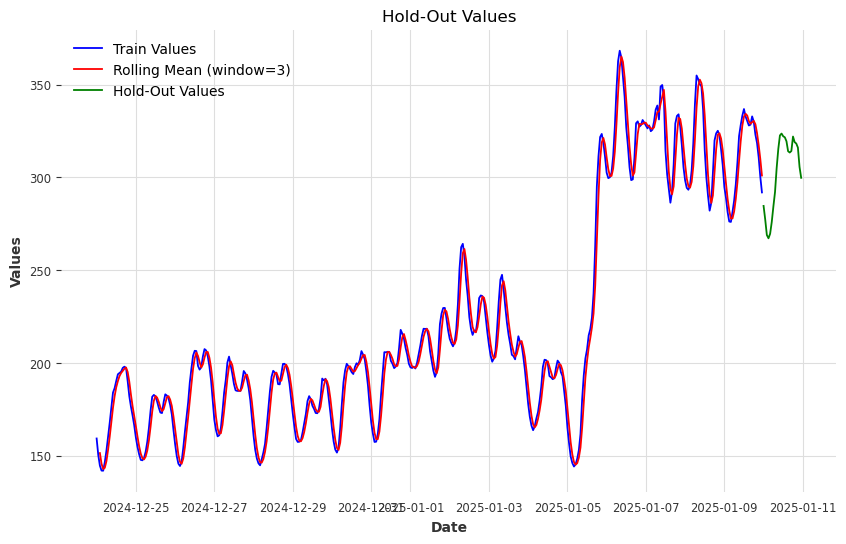

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure train and hold_out datasets are already defined
# Assuming train and hold_out data are from the split

# Scaling: Min-Max and Standardization (for train data only)
scaler_minmax = MinMaxScaler()
scaler_std = StandardScaler()

train_values = train["values"].values.reshape(-1, 1)  # Reshape for scalers
values_scaled_minmax = scaler_minmax.fit_transform(train_values)
values_scaled_std = scaler_std.fit_transform(train_values)

print("Min-Max Scaled Train Values:\n", values_scaled_minmax.flatten())
print("Standardized Train Values:\n", values_scaled_std.flatten())

# First Difference (for train data only)
values_diff = train["values"].diff().dropna()
print("First Difference:\n", values_diff.head())

# First and Second Derivative (Rate of Change and Acceleration) (for train data only)
values_gradient = np.gradient(train["values"].values)
values_acceleration = np.gradient(values_gradient)
print("First Derivative (Rate of Change):\n", values_gradient[:5])
print("Second Derivative (Acceleration):\n", values_acceleration[:5])

# Rolling Mean (for train data only)
rolling_mean = train["values"].rolling(window=3).mean()
print("Rolling Mean (window=3):\n", rolling_mean.head())

# Seasonal Decomposition (for train data only)
seasonal_decomposition = seasonal_decompose(
    train["values"], period=12, model="additive"
)
print("Seasonal Component Head:\n", seasonal_decomposition.seasonal.head())

# Create Lagged Features and Rate of Change (for train data only)
df_features_train = pd.DataFrame(
    {
        "value": train["values"],
        "lag_1": train["values"].shift(1),
        "lag_2": train["values"].shift(2),
        "rate_of_change": train["values"].diff(),
    }
).dropna()

# Adding Time-Based Features (for train data only)
df_features_train["month"] = train["date"].dt.month
df_features_train["year"] = train["date"].dt.year
print(
    "Time-Based Features (Train Data):\n", df_features_train[["month", "year"]].head()
)

# Save rolling mean plot for train data
plt.figure(figsize=(10, 6))
plt.plot(train["date"], train["values"], label="Train Values", color="Blue")
plt.plot(train["date"], rolling_mean, label="Rolling Mean (window=3)", color="Red")

plt.plot(hold_out["date"], hold_out["values"], label="Hold-Out Values", color="Green")
plt.title("Hold-Out Values")
plt.xlabel("Date")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.savefig("holdout_values_ercot.png")
plt.show()

MAPE: 3.96%


/var/folders/c8/g7bx7g1552g19xn4q4dd583r0000gn/T/ipykernel_45562/800740182.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hold_out['forecast'] = forecast_values.values


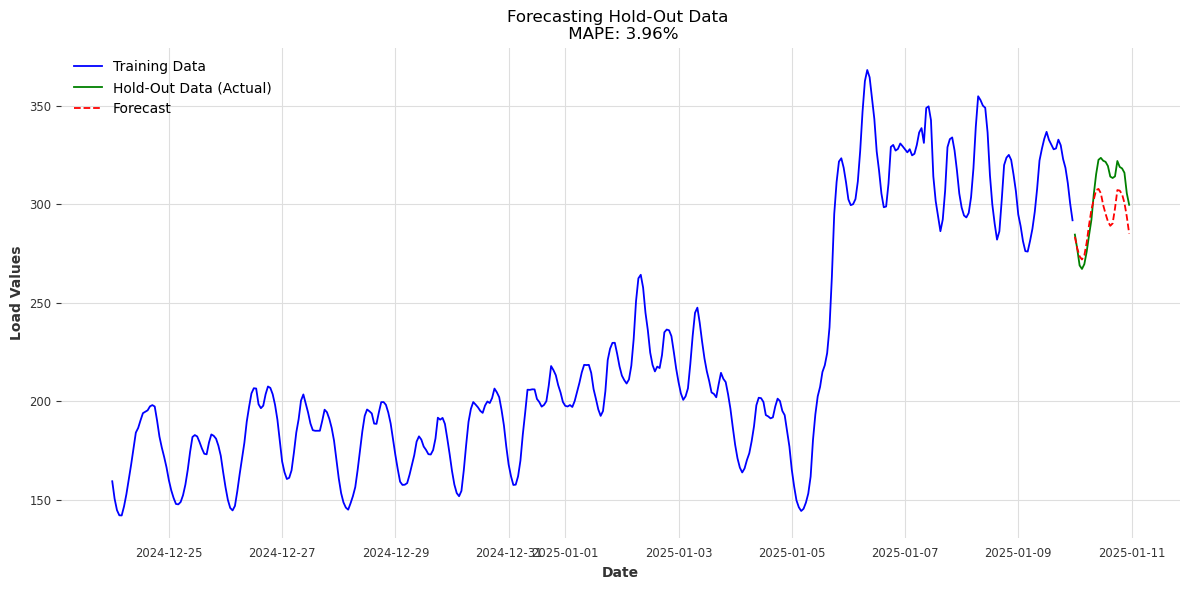

In [12]:
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit an Exponential Smoothing model on the training data
# Adjust seasonal_periods and trend/seasonal type as per data characteristics
model = ExponentialSmoothing(
    train["values"],
    trend="additive",
    seasonal="additive",
    seasonal_periods=24,  # Assuming daily seasonality in hourly data
)
fitted_model = model.fit()

# Forecast values for the hold-out period
forecast_values = fitted_model.forecast(steps=len(hold_out))

# Add forecast to the hold_out DataFrame for easier plotting
hold_out["forecast"] = forecast_values.values

# Calculate MAPE (Mean Absolute Percentage Error)
mape_value = mean_absolute_percentage_error(hold_out["values"], hold_out["forecast"])
print(f"MAPE: {mape_value * 100:.2f}%")

# Plot the results
plt.figure(figsize=(12, 6))

# Plot training data
plt.plot(train["date"], train["values"], label="Training Data", color="blue")

# Plot hold-out data
plt.plot(
    hold_out["date"], hold_out["values"], label="Hold-Out Data (Actual)", color="green"
)

# Plot forecasted data
plt.plot(
    hold_out["date"],
    hold_out["forecast"],
    label="Forecast",
    color="red",
    linestyle="--",
)

# Customize the plot
plt.title(f"Forecasting Hold-Out Data \n MAPE: {mape_value * 100:.2f}%")
plt.xlabel("Date")
plt.ylabel("Load Values")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the plot
plt.savefig("forecast_holdout_ercot.png")
plt.show()